# 03 • Optional: refine the selected RGB `cpsam_v2` prior with Proseg
Run this only after examining the direct image-model comparison. It adds a separate method
rather than overwriting Cellpose results, so improvements from the prior and from transcript-guided
refinement can be distinguished.

The runner uses your existing Proseg executable and checks its `--help` for every requested flag.
It uses actual Cellpose masks and the raw cell-probability field, preserves transcript IDs,
includes control features in the input, and compares output coverage explicitly.

In [1]:
from pathlib import Path
import sys
import importlib
import numpy as np
import pandas as pd

# Keep this notebook, pilot_config.json and cosmx_rgb_pilot.py together.
HERE = Path.cwd()
if not (HERE / "cosmx_rgb_pilot.py").exists():
    raise FileNotFoundError("Set HERE to the extracted notebook bundle directory.")
if str(HERE) not in sys.path:
    sys.path.insert(0, str(HERE))
import cosmx_rgb_pilot as pilot
importlib.reload(pilot)
CONFIG_PATH = HERE / "pilot_config.json"
config = pilot.read_json(CONFIG_PATH)
OUTPUT_ROOT = Path(config["output_root"])
for sample_spec in config["samples"].values():
    source_path = Path(sample_spec["source_zarr"]).resolve()
    output_path = OUTPUT_ROOT.resolve()
    if output_path == source_path or source_path in output_path.parents or output_path in source_path.parents:
        raise ValueError("The pilot output root must be separate from every source Zarr.")
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
print("Output root:", OUTPUT_ROOT)

Output root: /host_root/nethome/reny28/Projects/CosMX_projects/P06364_CRC_DS20250227_48371/tmp/DS-20250227-48371/cpsam_v2_rgb_softstitch_pilot_v1


### Important ID and coordinate details
Proseg's output **cell ID 0 is a valid cell**. It is not treated as background. The helper uses
the nullable assignment plus the background flag and records an explicit `Proseg ID → raster ID+1`
map so raster zero can remain background. GeoJSON cell IDs are read from properties, never
inferred from feature row order.

Input transcript coordinates are tile-local microns. Exactly one mask-coordinate representation
is passed: `--cellpose-x-transform` and `--cellpose-y-transform`; `--cellpose-scale` is not also
passed. The explicit pixel-center offset is included in this mapping.

Whole-cell RGB priors are not nuclear-only priors. Your previous compactness setting remains a
starting point, not a demonstrated optimum for this different prior type. More Proseg iterations
should be assessed empirically, not assumed to guarantee better segmentation.

Sources: [Proseg v3.1.1 CLI](https://github.com/dcjones/proseg/blob/v3.1.1/src/main.rs),
[Proseg v3.1.1 output semantics](https://github.com/dcjones/proseg/blob/v3.1.1/src/output.rs).

In [2]:
SAMPLE_TO_REFINE = "B20317610105_colon"
PRIOR_METHOD = "rgb_v2_legacy_thresholds"
tiles = sorted(p.parent for p in (OUTPUT_ROOT / SAMPLE_TO_REFINE / "tiles").glob("*/complete.json"))
if not tiles:
    raise RuntimeError("Prepare and segment pilot tiles first.")
tile_path = tiles[0]
print("Tile:", tile_path)
print("Prior:", PRIOR_METHOD)
print("Executable:", config["proseg_bin"])
display(pd.Series(config["proseg_pilot"], name="pilot_parameters"))

Tile: /host_root/nethome/reny28/Projects/CosMX_projects/P06364_CRC_DS20250227_48371/tmp/DS-20250227-48371/cpsam_v2_rgb_softstitch_pilot_v1/B20317610105_colon/tiles/pilot_00_vertical_seam
Prior: rgb_v2_legacy_thresholds
Executable: /home/domino/reny28/Projects/CosMX_projects/P06364_CRC_DS20250227_48371/code/Bash/.tools/bin/proseg


cell_compactness      0.025
samples              60.000
burnin_samples       60.000
recorded_samples     30.000
hillclimb            20.000
nthreads              8.000
voxel_size            1.000
burnin_voxel_size     2.000
voxel_layers          1.000
Name: pilot_parameters, dtype: float64

In [3]:
RUN_PROSEG = False
if RUN_PROSEG:
    proseg_path = pilot.run_proseg_refinement(
        tile_path, PRIOR_METHOD, config["proseg_bin"], config["proseg_pilot"],
        output_method=PRIOR_METHOD + "_proseg_pilot",
    )
    print(proseg_path)
    for method in ["native", PRIOR_METHOD, PRIOR_METHOD + "_proseg_pilot"]:
        pilot.plot_tile(tile_path, method)
    updated_metrics, updated_cells = pilot.compare_tile(tile_path, border_band_um=config["border_band_um"])
    display(updated_metrics)
else:
    print("Proseg is optional and disabled until RUN_PROSEG=True.")

Proseg is optional and disabled until RUN_PROSEG=True.


/host_root/nethome/reny28/Projects/CosMX_projects/P06364_CRC_DS20250227_48371/tmp/DS-20250227-48371/cpsam_v2_rgb_softstitch_pilot_v1/B20317610105_colon/tiles/pilot_00_vertical_seam/methods/rgb_v2_legacy_thresholds_proseg_pilot


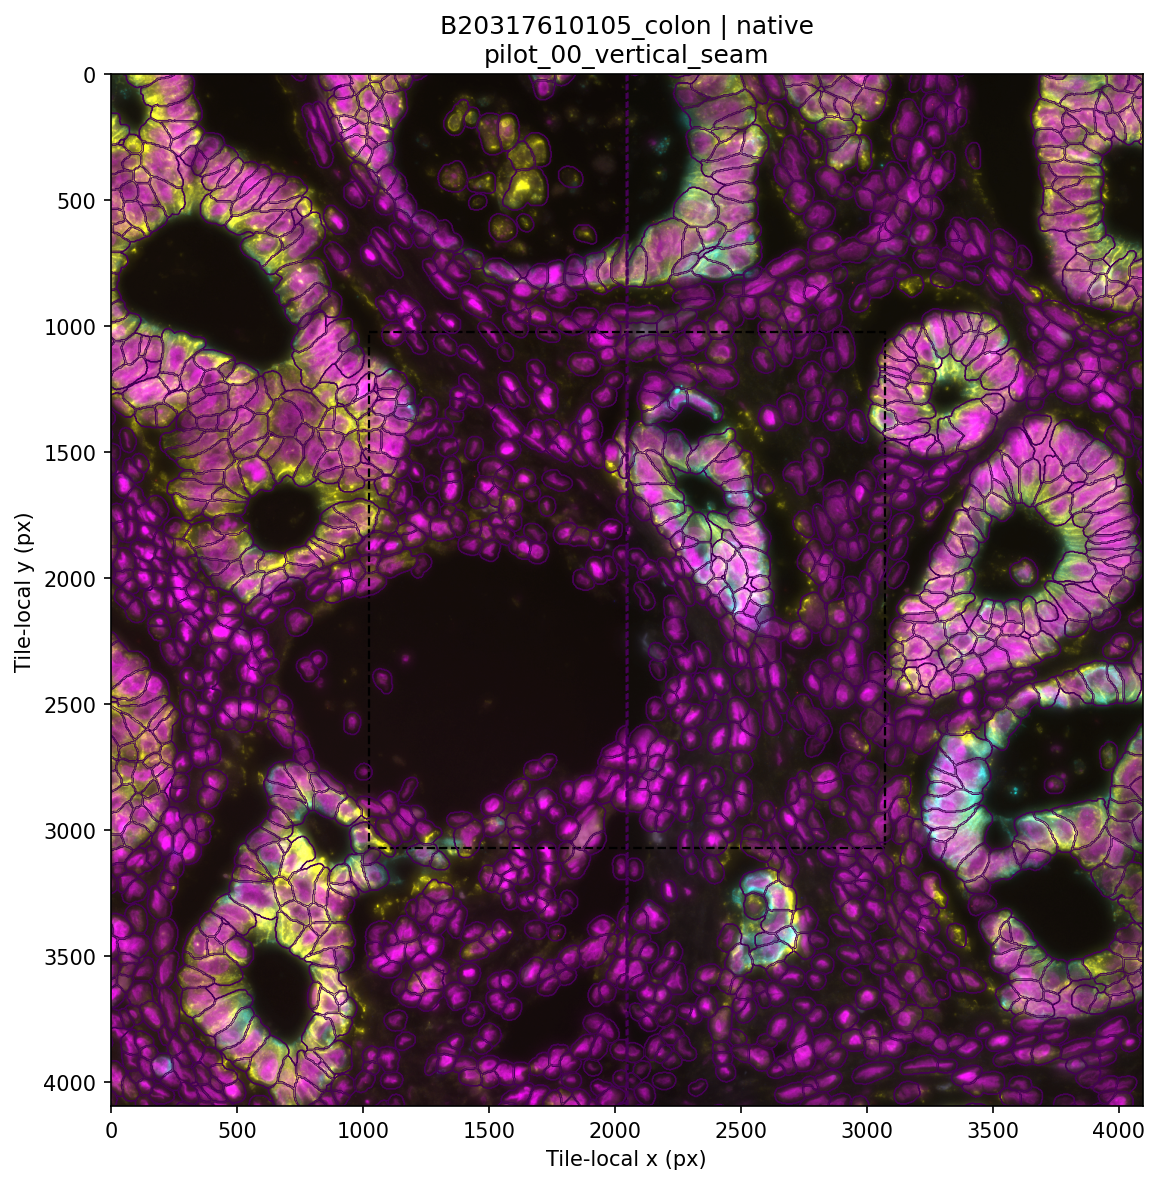

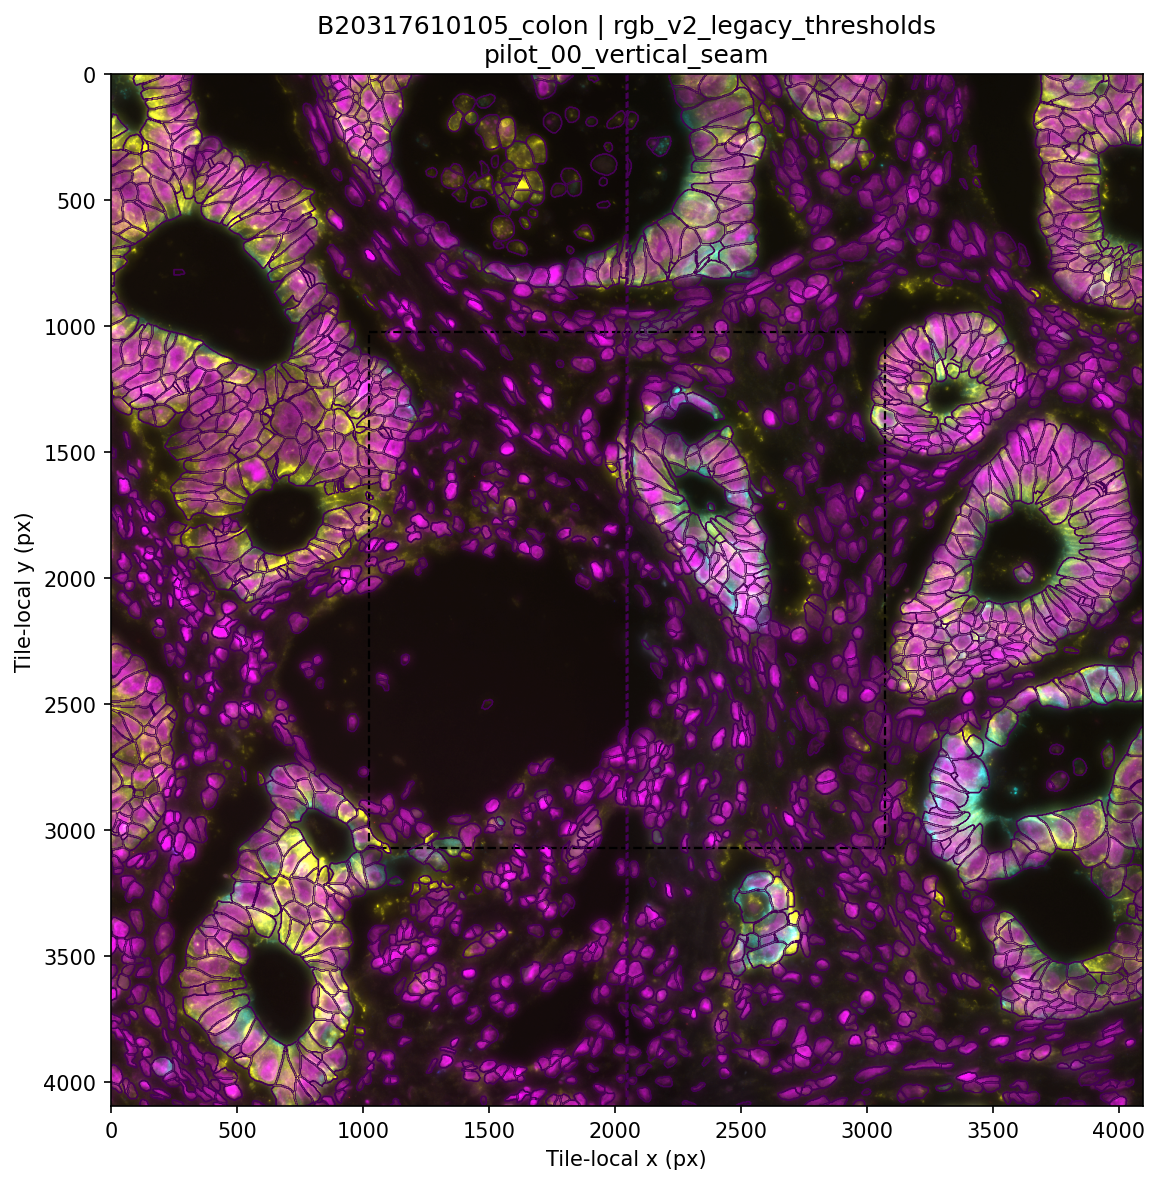

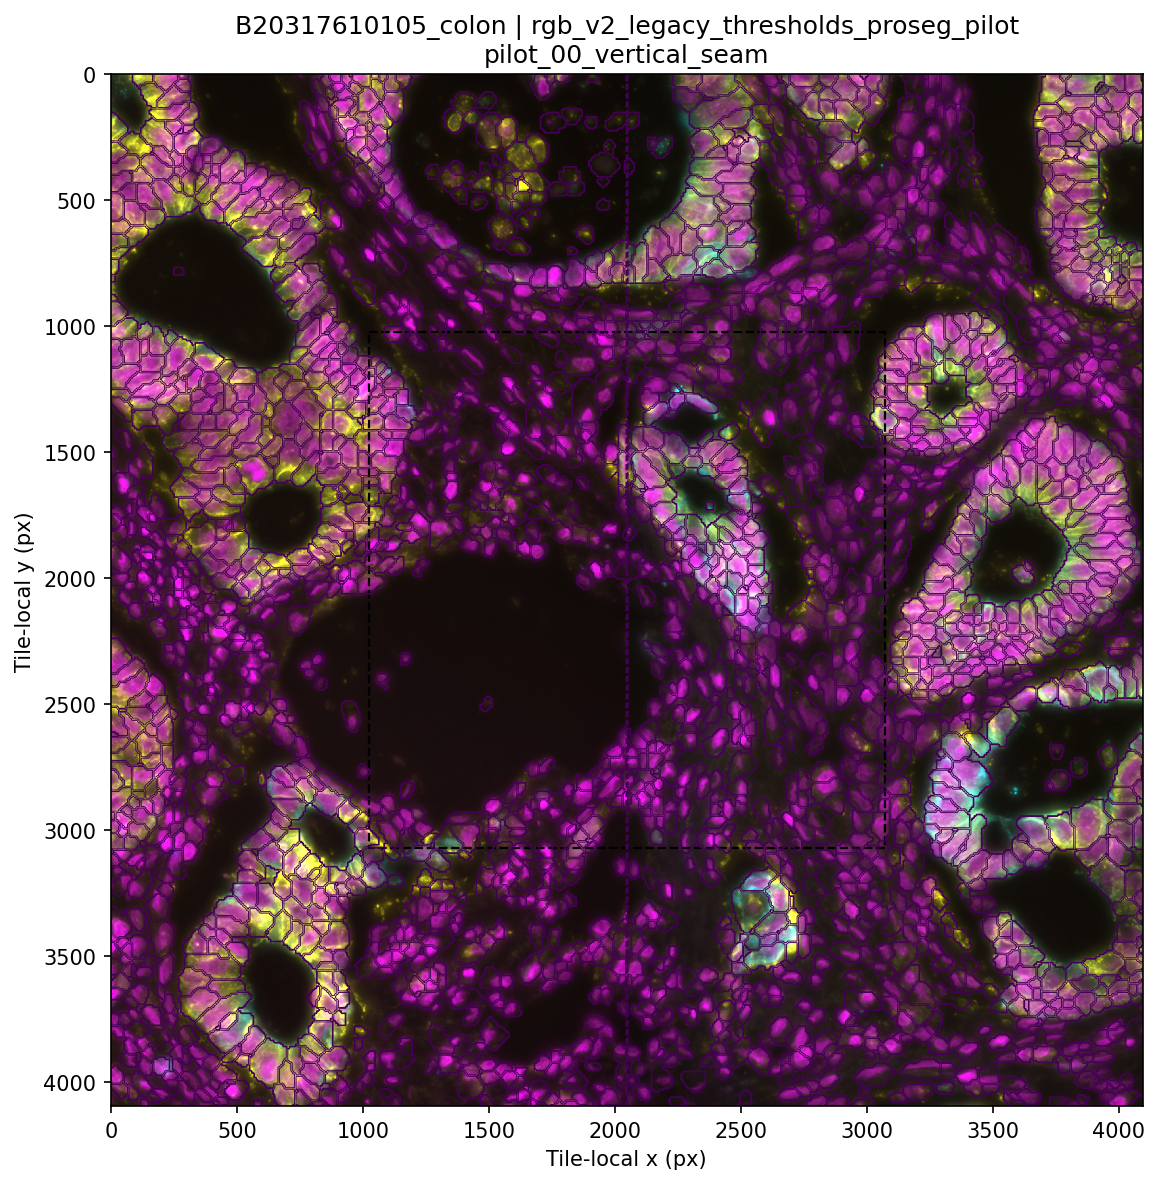

,sample,tile_id,method,region,border_band_um,observed_area_um2,n_cells_centroid,cells_per_mm2,median_area_um2,median_nCount_RNA,...,object_recall_vs_native,object_f1_vs_native,split_native_fraction,merged_candidate_fraction,n_transcripts_evaluated,assigned_fraction,native_assigned_fraction,jointly_assigned_fraction,native_fg_recovery,ari_jointly_assigned
0,B20317610105_colon,pilot_00_vertical_seam,native,core,50.0,60680.163662,349,5751.467678,79.222817,324.0,...,1.000000,1.000000,0.000000,0.000000,185182,0.826700,0.826700,0.826700,1.000000,1.000000
1,B20317610105_colon,pilot_00_vertical_seam,native,old_border_band,50.0,24651.316488,147,5963.170368,78.499453,281.0,...,1.000000,1.000000,0.000000,0.000000,74050,0.835111,0.835111,0.835111,1.000000,1.000000
2,B20317610105_colon,pilot_00_vertical_seam,native,interior,50.0,36028.847174,202,5606.618469,79.852143,355.0,...,1.000000,1.000000,0.000000,0.000000,111132,0.821096,0.821096,0.821096,1.000000,1.000000
3,B20317610105_colon,pilot_00_vertical_seam,blue_v2_legacy_thresholds,core,50.0,60680.163662,448,7382.972836,30.656163,159.5,...,0.270619,0.240550,0.265464,0.158763,185182,0.598055,0.826700,0.580478,0.702162,0.749381
4,B20317610105_colon,pilot_00_vertical_seam,blue_v2_legacy_thresholds,old_border_band,50.0,24651.316488,196,7950.893823,31.683340,141.5,...,0.300578,0.265985,0.283237,0.169725,74050,0.640986,0.835111,0.624402,0.747688,0.764254
5,B20317610105_colon,pilot_00_vertical_seam,blue_v2_legacy_thresholds,interior,50.0,36028.847174,252,6994.395318,30.634462,185.0,...,0.252000,0.231618,0.236000,0.146259,111132,0.569449,0.821096,0.551209,0.671310,0.754742
6,B20317610105_colon,pilot_00_vertical_seam,rgb_v2_balanced,core,50.0,60680.163662,410,6756.738533,24.919887,135.0,...,0.139175,0.130120,0.177835,0.099548,185182,0.475905,0.826700,0.465942,0.563616,0.805274
7,B20317610105_colon,pilot_00_vertical_seam,rgb_v2_balanced,old_border_band,50.0,24651.316488,177,7180.143912,23.986748,112.0,...,0.150289,0.142077,0.184971,0.129534,74050,0.513315,0.835111,0.504308,0.603881,0.773414
8,B20317610105_colon,pilot_00_vertical_seam,rgb_v2_balanced,interior,50.0,36028.847174,233,6467.040116,25.187532,145.0,...,0.124000,0.119461,0.160000,0.074349,111132,0.450977,0.821096,0.440377,0.536329,0.853932
9,B20317610105_colon,pilot_00_vertical_seam,rgb_v2_independent_fovs,core,50.0,60680.163662,518,8536.562342,29.882164,148.5,...,0.301546,0.246057,0.337629,0.138544,185182,0.635267,0.826700,0.613964,0.742668,0.738987


In [4]:
RUN_PROSEG = True
if RUN_PROSEG:
    proseg_path = pilot.run_proseg_refinement(
        tile_path, PRIOR_METHOD, config["proseg_bin"], config["proseg_pilot"],
        output_method=PRIOR_METHOD + "_proseg_pilot",
    )
    print(proseg_path)
    for method in ["native", PRIOR_METHOD, PRIOR_METHOD + "_proseg_pilot"]:
        pilot.plot_tile(tile_path, method)
    updated_metrics, updated_cells = pilot.compare_tile(tile_path, border_band_um=config["border_band_um"])
    display(updated_metrics)
else:
    print("Proseg is optional and disabled until RUN_PROSEG=True.")

### Optional longer confirmation run
The full setting reproduces 300 sampling iterations, 300 burn-in iterations, 100 recorded
samples, compactness 0.025 and hillclimb 50 from your working pipeline. Its output name differs
from the short pilot, so both remain available. The Proseg seed is not controlled by this helper;
small run-to-run differences should not be overinterpreted.

In [5]:
RUN_LONG_CONFIRMATION = False
if RUN_LONG_CONFIRMATION:
    final_path = pilot.run_proseg_refinement(
        tile_path, PRIOR_METHOD, config["proseg_bin"], config["proseg_final"],
        output_method=PRIOR_METHOD + "_proseg_final",
    )
    print(final_path)
    metrics, cell_metrics = pilot.compare_all(config)
    display(metrics[metrics["sample"] == SAMPLE_TO_REFINE])

In [6]:
RUN_LONG_CONFIRMATION = True
if RUN_LONG_CONFIRMATION:
    final_path = pilot.run_proseg_refinement(
        tile_path, PRIOR_METHOD, config["proseg_bin"], config["proseg_final"],
        output_method=PRIOR_METHOD + "_proseg_final",
    )
    print(final_path)
    metrics, cell_metrics = pilot.compare_all(config)
    display(metrics[metrics["sample"] == SAMPLE_TO_REFINE])

/host_root/nethome/reny28/Projects/CosMX_projects/P06364_CRC_DS20250227_48371/tmp/DS-20250227-48371/cpsam_v2_rgb_softstitch_pilot_v1/B20317610105_colon/tiles/pilot_00_vertical_seam/methods/rgb_v2_legacy_thresholds_proseg_final


,sample,tile_id,method,region,border_band_um,observed_area_um2,n_cells_centroid,cells_per_mm2,median_area_um2,median_nCount_RNA,...,object_recall_vs_native,object_f1_vs_native,split_native_fraction,merged_candidate_fraction,n_transcripts_evaluated,assigned_fraction,native_assigned_fraction,jointly_assigned_fraction,native_fg_recovery,ari_jointly_assigned
0,B20317610105_colon,pilot_00_vertical_seam,native,core,50.0,60680.163662,349,5751.467678,79.222817,324.0,...,1.000000,1.000000,0.000000,0.000000,185182,0.826700,0.826700,0.826700,1.000000,1.000000
1,B20317610105_colon,pilot_00_vertical_seam,native,old_border_band,50.0,24651.316488,147,5963.170368,78.499453,281.0,...,1.000000,1.000000,0.000000,0.000000,74050,0.835111,0.835111,0.835111,1.000000,1.000000
2,B20317610105_colon,pilot_00_vertical_seam,native,interior,50.0,36028.847174,202,5606.618469,79.852143,355.0,...,1.000000,1.000000,0.000000,0.000000,111132,0.821096,0.821096,0.821096,1.000000,1.000000
3,B20317610105_colon,pilot_00_vertical_seam,blue_v2_legacy_thresholds,core,50.0,60680.163662,448,7382.972836,30.656163,159.5,...,0.270619,0.240550,0.265464,0.158763,185182,0.598055,0.826700,0.580478,0.702162,0.749381
4,B20317610105_colon,pilot_00_vertical_seam,blue_v2_legacy_thresholds,old_border_band,50.0,24651.316488,196,7950.893823,31.683340,141.5,...,0.300578,0.265985,0.283237,0.169725,74050,0.640986,0.835111,0.624402,0.747688,0.764254
5,B20317610105_colon,pilot_00_vertical_seam,blue_v2_legacy_thresholds,interior,50.0,36028.847174,252,6994.395318,30.634462,185.0,...,0.252000,0.231618,0.236000,0.146259,111132,0.569449,0.821096,0.551209,0.671310,0.754742
6,B20317610105_colon,pilot_00_vertical_seam,rgb_v2_balanced,core,50.0,60680.163662,410,6756.738533,24.919887,135.0,...,0.139175,0.130120,0.177835,0.099548,185182,0.475905,0.826700,0.465942,0.563616,0.805274
7,B20317610105_colon,pilot_00_vertical_seam,rgb_v2_balanced,old_border_band,50.0,24651.316488,177,7180.143912,23.986748,112.0,...,0.150289,0.142077,0.184971,0.129534,74050,0.513315,0.835111,0.504308,0.603881,0.773414
8,B20317610105_colon,pilot_00_vertical_seam,rgb_v2_balanced,interior,50.0,36028.847174,233,6467.040116,25.187532,145.0,...,0.124000,0.119461,0.160000,0.074349,111132,0.450977,0.821096,0.440377,0.536329,0.853932
9,B20317610105_colon,pilot_00_vertical_seam,rgb_v2_independent_fovs,core,50.0,60680.163662,518,8536.562342,29.882164,148.5,...,0.301546,0.246057,0.337629,0.138544,185182,0.635267,0.826700,0.613964,0.742668,0.738987


The resulting folders contain Proseg logs, the exact command, polygon GeoJSON, transcript
metadata, assignments, ID mappings, and a native-resolution comparison mask. Missing output
transcripts are reported through `assignment_output_coverage`; they are not silently assumed to
have been returned. Rasterization overlap is also reported. Keep the Cellpose-only result if
Proseg worsens a region despite a strong whole-cell prior.